In [1]:
%matplotlib inline
import csv
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib
import scipy.interpolate as interpolate
import scipy.signal as signal
from matplotlib.patches import Rectangle
import scipy.stats as stats
import scipy.constants as const
import scipy.optimize as optimize
import scipy.interpolate as interpolate
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm  # For register_cmap
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.signal import find_peaks
from matplotlib.ticker import MaxNLocator, FixedLocator

**Settings** 

In [2]:
custom_blue = (0.0, 0.5, 0.9, 1.0)  # RGB for blue (#0099FF)

original_cmap = plt.get_cmap('RdGy_r')
n_colors = 256
colors = original_cmap(np.linspace(0, 1, n_colors))

colors[128:256, :] = np.linspace([0.5, 0.5, 0.5,0], custom_blue, 128)  # Fade from gray to blue
custom_cmap = ListedColormap(colors)

dark_red = np.array([0.7, 0.05, 0.15, 1.0], dtype=np.float64)

custom_green = (13/256, 179/256, 45/256, 1.0)
custom_blue = (34/255, 125/255, 251/255, 1)  # RGB for blue #227DFB
custom_red = (209/255, 37/255, 55/255, 1)  # RGB for red #D1254E

original_cmap = plt.get_cmap('RdGy_r')
n_colors = 256
colorsB = original_cmap(np.linspace(0, 1, n_colors))

colorsB[128:256, :] = np.linspace([0.5, 0.5, 0.5,0], custom_blue, 128)  # Fade from gray to blue
custom_cmap_blue = ListedColormap(colorsB)

original_cmap = plt.get_cmap('RdGy_r')
n_colors = 256
colorsR = original_cmap(np.linspace(0, 1, n_colors))

colorsR[128:256, :] = np.linspace([0.5, 0.5, 0.5,0], custom_red, 128)  # Fade from gray to blue
custom_cmap_red = ListedColormap(colorsR)

matplotlib.rcParams.update({
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'legend.fontsize': 18,
    # 'text.usetex': True
})

# Device D

## Weak Electron

Measurement (i)

['Channels', 'Data', 'Instrument config', 'Instruments', 'Log list', 'Settings', 'Step config', 'Step list', 'Tags', 'Views']
[np.void((b'V_SD Left C18 C6', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'PG Virtual', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_MG C17', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'V_PG Left C24', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I_SD Left C18', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I SD C18 AC x', b''), dtype=[('name', 'O'), ('info', 'O')]), np.void((b'I SD C18 AC theta', b''), dtype=[('name', 'O'), ('info', 'O')])]


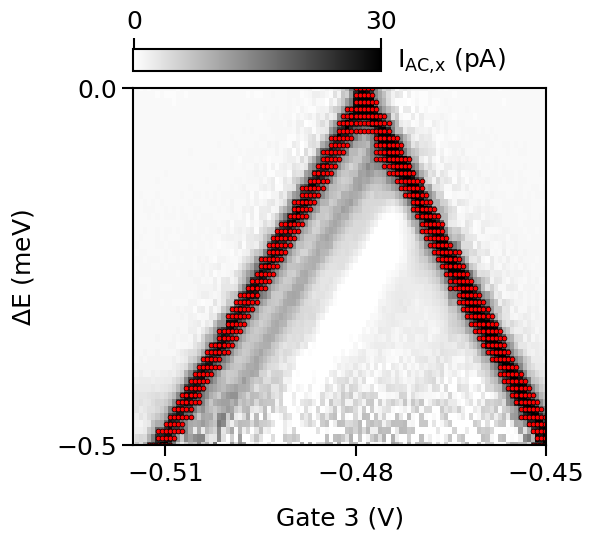

In [ ]:
name='C0062 4VBGm 1e Diamond MG'
filename='Z:/POBox/Jonas Gerber/05 - Measurements (Data)/EE01/Fritz2025 Cooldown C/2025/07/Data_0716/%s.hdf5'%name
data = h5py.File(filename, 'r')

# print([i for i in data])#Open just for reading "r"
# print([i for i in data['Data']['Channel names']])

V_SD=data['Data']['Data'][:,0,:] * 2
# print(V_PGv)
V_PG=data['Data']['Data'][:,1,:]
# print(Bz)
I_ACx=data['Data']['Data'][:,5,:]*1e-8
# Convert raw data to physical units
y_all = V_PG[:, 0:101]  # Gate 3 (V)
x_all = V_SD[:, 0:101]  # B⊥ (mT)
z_all = I_ACx[:, 0:101] * 1e12  # pA

# Choose a y value above which data should be shifted
y_jump_value = 0  # V (Gate 3)
x_shift = 0  # mT shift for y > y_jump_value

# Shift the x values *before* filtering
x_shifted = np.copy(x_all)
x_shifted[y_all > y_jump_value] += x_shift

# Define the desired x and y range
x_range = (-0.515, -0.450)  # for Gate 3 (V)
y_range = (-0.5, 0)  # for B⊥ (mT)

# Since x_shift=0 and ranges include all data, mask is effectively all True, but kept for generality
mask = (x_shifted >= x_range[0]) & (x_shifted <= x_range[1]) & \
       (y_all >= y_range[0]) & (y_all <= y_range[1])

# Compute grid centers
x_centers = y_all[0, :]  # Unique Gate 3 values (assuming constant along columns)
y_centers = x_all[:, 0]  # Unique B⊥ values (assuming constant along rows)

# Compute edges for pcolormesh
x_diffs = np.diff(x_centers)
x_edges = np.concatenate(([x_centers[0] - x_diffs[0] / 2],
                          (x_centers[:-1] + x_centers[1:]) / 2,
                          [x_centers[-1] + x_diffs[-1] / 2]))

y_diffs = np.diff(y_centers)
y_edges = np.concatenate(([y_centers[0] - y_diffs[0] / 2],
                          (y_centers[:-1] + y_centers[1:]) / 2,
                          [y_centers[-1] + y_diffs[-1] / 2]))

# Set the min and max values for the colorbar
z_min = 30
z_max = 0

# Define colorbar ticks [not used at the moment, defined by MaxNLocator instead]
# cbar_ticks = np.linspace(z_min, z_max, 3)  # e.g., [40, 20, 0]

# Create figure
fig = plt.figure(figsize=(5.5, 5.5), dpi=100)


# Add axes for the pcolormesh plot (leaving space at top for colorbar)
ax = fig.add_axes([0.15, 0.15, 0.75, 0.65])  # [left, bottom, width, height]

# Use pcolormesh with swapped axes
pcm = ax.pcolormesh(x_edges, y_edges, z_all, cmap='binary', vmin=z_min, vmax=z_max)

# Set labels and limits
ax.set_xlabel(r'Gate 3 (V)', labelpad=15, fontsize=18)
ax.set_ylabel(r'$\Delta$E (meV)', labelpad=15, fontsize=18)
ax.set_xlim(x_range)  # Gate 3 range (V)
ax.set_ylim(y_range)  # B⊥ range (mT)
ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
ax.yaxis.set_major_locator(FixedLocator([-0.5, 0]))  # Explicitly set y-ticks
ax.xaxis.set_major_locator(FixedLocator([-0.51,-0.48,-0.45]))  # Explicitly set y-ticks
ax.tick_params(labelsize=18)

# Add colorbar above the plot
cbar_ax = fig.add_axes([0.15, 0.83, 0.45, 0.04])  # Colorbar: 2/3 width
cb = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal')
cb.ax.tick_params(labelsize=18, direction='out', which='major', top=True, bottom=False, labeltop=True, labelbottom=False)
cb.locator = MaxNLocator(nbins=1)
cb.update_ticks()

# Add colorbar label in a separate axes to the right of the colorbar
label_ax = fig.add_axes([0.63, 0.825, 0.35, 0.05])  # Label: 1/3 width
label_ax.axis('off')  # Hide axes
label_ax.text(0, 0.5, r'I$_\text{AC,x}$ (pA)', fontsize=18, va='center', ha='left')

z_min = z_all.min()
z_max = z_all.max()
z_difference = z_max - z_min
threshold = z_min + 0.5 * z_difference

z_above_threshold = z_all >= threshold
# plot all z above threshold over the original pcolormesh plot
ax.scatter(y_all[z_above_threshold], x_all[z_above_threshold],
           s=12, color='red', edgecolors='k', linewidths=0.5)
plt.show()
